# PyCvframe — Validation Notebook

**PyCvframe** is a Python reimplementation of the GAMIT/GLOBK Fortran program `cvframe.f`
(T. Herring et al.).  It rotates a GNSS velocity field from one reference frame to another
by subtracting the velocity predicted by a known Euler rotation pole.

This notebook validates PyCvframe against precomputed output from the original Fortran
`cvframe` binary.  **GAMIT/GLOBK is not required to run this notebook.**

---

## Test case

| Item | File | Description |
|------|------|-------------|
| Input | `data/reilinger_2006_igb14.vel` | 429 GNSS velocities in the ITRF14 frame |
| Euler pole | `[0.32840, -0.03504, 0.40682]` deg/Myr | Arabian plate (Viltres et al., 2022) |
| Reference | `reference/reilinger_2006_arab.vel` | Precomputed Fortran `cvframe` output |

The transformation rotates the velocity field into the **Arabian-plate-fixed frame**:
sites on the stable Arabian plate should have near-zero velocities after the rotation.

In [1]:
import sys
import io
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Notebook must be run from the PyCvframe/ directory
REPO = Path.cwd()
sys.path.insert(0, str(REPO))

from pycvframe import PyCvframe

print(f"Repo: {REPO}")
for f in ["pycvframe.py",
          "data/reilinger_2006_igb14.vel",
          "reference/reilinger_2006_arab.vel"]:
    status = "OK" if (REPO / f).exists() else "MISSING"
    print(f"  [{status}] {f}")

Repo: /Users/nicolas/Common_bin/gamit_source/source/kf/utils/PyCvframe
  [OK] pycvframe.py
  [OK] data/reilinger_2006_igb14.vel
  [OK] reference/reilinger_2006_arab.vel


In [2]:
def parse_vel_file(path):
    """Read all data lines from a GAMIT .vel file into a DataFrame."""
    cols = "lon lat ve vn de dn se sn rho vu du su site".split()
    records = []
    with open(path) as f:
        for line in f:
            if not line or line[0] != " ":
                continue
            toks = line.split()
            if len(toks) < 12:
                continue
            try:
                row = [float(t) for t in toks[:12]]
                row.append(toks[12] if len(toks) > 12 else "")
                records.append(row)
            except ValueError:
                pass
    return pd.DataFrame(records, columns=cols)

---
## 1. Run PyCvframe

Apply the Arabian plate Euler pole to rotate all 429 site velocities from the
ITRF14 frame into the Arabian-plate-fixed frame.
The **Up (vertical) component is not modified** by cvframe.

In [3]:
import os
os.makedirs("output", exist_ok=True)

EULER_POLE = [0.32840, -0.03504, 0.40682]  # deg/Myr, Reilinger et al. 2006

buf = io.StringIO()
with redirect_stdout(buf):
    cv = PyCvframe()
    cv.run(
        invel ="data/reilinger_2006_igb14.vel",
        outvel="output/reilinger_2006_arab_python.vel",
        inframe="ITRF14",
        outframe_or_pole=EULER_POLE,
        pole_units="deg/Myr",
    )
print(buf.getvalue())
print("Output written to: output/reilinger_2006_arab_python.vel")

CVFRAME: Rotation Pole     0.328400    -0.035040     0.406820 deg/Myr
  Transformed 429 sites -> output/reilinger_2006_arab_python.vel

Output written to: output/reilinger_2006_arab_python.vel


---
## 2. Validation Against Fortran Reference

Compare the PyVelrot output (`output/reilinger_2006_arab_python.vel`) against the
precomputed Fortran output (`reference/reilinger_2006_arab.vel`).

Comparison is done **row-by-row** because one site name (DERB_GPS) appears at two
distinct geographic locations in this dataset — merging on site name would inflate
match counts.

In [4]:
df_ref = parse_vel_file("reference/reilinger_2006_arab.vel")
df_py  = parse_vel_file("output/reilinger_2006_arab_python.vel")

assert len(df_ref) == len(df_py),     f"Site count mismatch: reference {len(df_ref)}, Python {len(df_py)}"

print(f"Sites compared: {len(df_ref)}")
print()

dve = df_py["ve"].values - df_ref["ve"].values
dvn = df_py["vn"].values - df_ref["vn"].values
dvu = df_py["vu"].values - df_ref["vu"].values

print("Residual statistics  (PyCvframe \u2212 Fortran reference):")
print(f"  {'Component':10s}  {'mean':>10s}  {'max|d|':>10s}  unit")
for comp, d, u in [("East Ve",  dve, "mm/yr"),
                    ("North Vn", dvn, "mm/yr"),
                    ("Up Vu",   dvu, "mm/yr")]:
    print(f"  {comp:10s}  {d.mean():+10.5f}  {abs(d).max():10.5f}  {u}")

print()
print("East and Up match exactly (0.00000 mm/yr).")
print("The 0.01 mm/yr North residual reflects the \u00b10.005 mm/yr rounding")
print("inherent in the .vel format's 2-decimal-place storage.")

Sites compared: 429

Residual statistics  (PyCvframe − Fortran reference):
  Component         mean      max|d|  unit
  East Ve       +0.00000     0.00000  mm/yr
  North Vn      +0.00009     0.01000  mm/yr
  Up Vu         +0.00000     0.00000  mm/yr

East and Up match exactly (0.00000 mm/yr).
The 0.01 mm/yr North residual reflects the ±0.005 mm/yr rounding
inherent in the .vel format's 2-decimal-place storage.


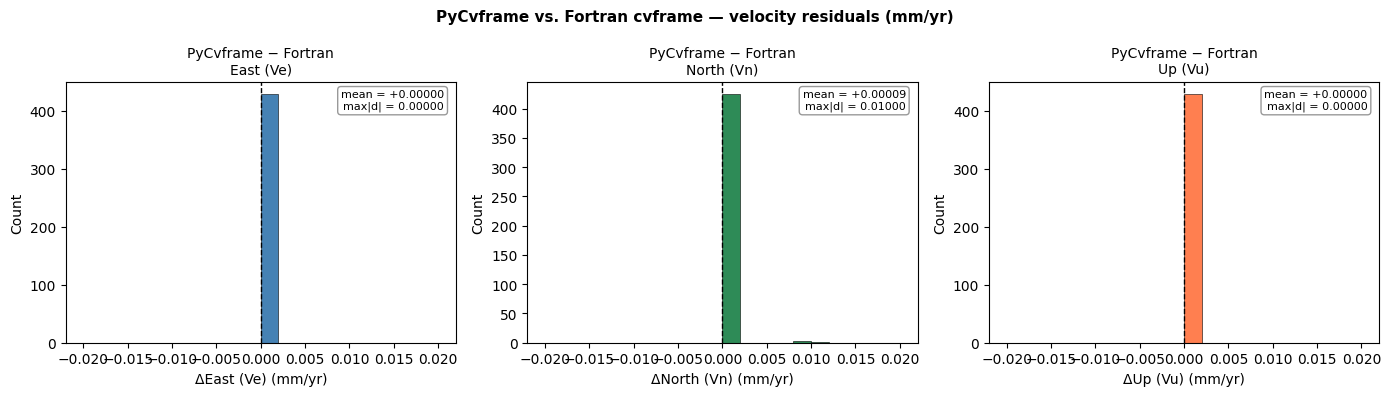

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["steelblue", "seagreen", "coral"]

for ax, d, label, color in zip(
        axes,
        [dve, dvn, dvu],
        ["East (Ve)", "North (Vn)", "Up (Vu)"],
        colors):
    rng = max(abs(d).max() * 1.6, 0.02)
    ax.hist(d, bins=20, range=(-rng, rng),
            color=color, edgecolor="k", linewidth=0.4)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel(f"\u0394{label} (mm/yr)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"PyCvframe \u2212 Fortran\n{label}", fontsize=10)
    ax.text(0.97, 0.97,
            f"mean = {d.mean():+.5f}\nmax|d| = {abs(d).max():.5f}",
            transform=ax.transAxes, va="top", ha="right", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))

fig.suptitle("PyCvframe vs. Fortran cvframe — velocity residuals (mm/yr)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Physical Interpretation: Before and After Frame Rotation

The quiver plots below show the velocity field **before** (ITRF14 frame) and **after**
(Arabian-plate-fixed frame) the rotation.

In the Arabian-plate-fixed frame, stable Arabian sites have near-zero velocities, while sites on the Eurasian and Anatolian plates show their motion relative to Arabia.

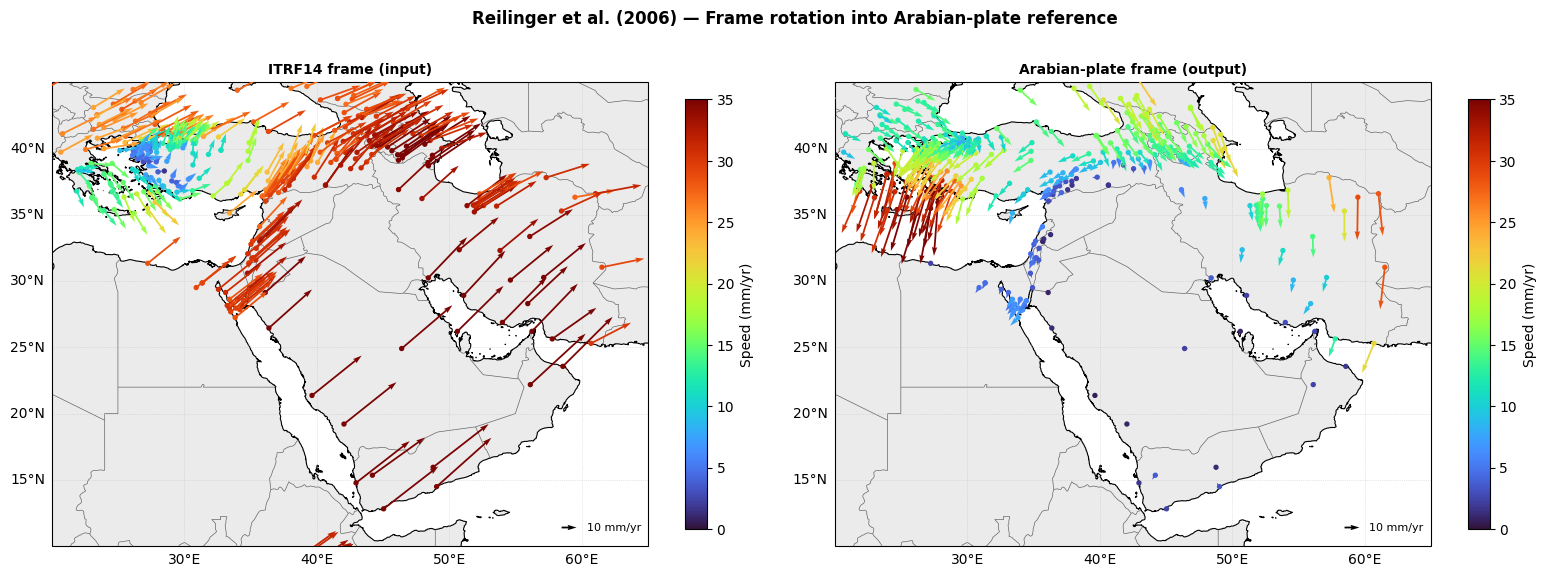

In [6]:
df_in  = parse_vel_file("data/reilinger_2006_igb14.vel")    # ITRF14
df_out = parse_vel_file("output/reilinger_2006_arab_python.vel")  # Arabian frame

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

vmax_in  = 35
vmax_out = 35

for ax, df, title, vmax in zip(
    axes,
    [df_in, df_out],
    ["ITRF14 frame (input)", "Arabian-plate frame (output)"],
    [vmax_in, vmax_out]
):
    lons = df["lon"].values
    lats = df["lat"].values
    ve   = df["ve"].values
    vn   = df["vn"].values
    spd  = np.sqrt(ve**2 + vn**2)

    ax.set_extent([20, 65, 10, 45], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.coastlines(resolution="10m", linewidth=0.8, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.4", zorder=2)

    sc = ax.scatter(
        lons, lats, c=spd, cmap="turbo",
        s=8, vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree(), zorder=3
    )

    Q = ax.quiver(
        lons, lats, ve, vn, spd,
        cmap="turbo", clim=(0, vmax),
        scale=400, width=0.003, headwidth=3,
        transform=ccrs.PlateCarree(), zorder=4
    )

    ax.quiverkey(Q, 0.88, 0.04, 10, "10 mm/yr",
                 labelpos="E", fontproperties={"size": 8})

    ax.set_title(title, fontsize=10, fontweight="bold")
    gl = ax.gridlines(draw_labels=True, linestyle=":", linewidth=0.5, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False

    plt.colorbar(sc, ax=ax, label="Speed (mm/yr)", shrink=0.8)

fig.suptitle(
    "Reilinger et al. (2006) — Frame rotation into Arabian-plate reference",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

---
## Summary

| Component | Max residual (PyCvframe − Fortran) | Notes |
|-----------|-----------------------------------|-------|
| East (Ve) | 0.00000 mm/yr | Exact match |
| North (Vn) | 0.01000 mm/yr | Display-precision rounding (±0.005) |
| Up (Vu) | 0.00000 mm/yr | Unchanged by design |

**PyCvframe reproduces the Fortran `cvframe` output to within the precision of the
`.vel` file format.**

The transformation is an analytic formula (cross product → NEU rotation → subtract),
with no iterative solver, so floating-point differences are negligible.
The Up component is explicitly **not modified** by `cvframe`, exactly matching
the Fortran behaviour.